In [13]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, FixedLocator
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import MultipleLocator
from matplotlib.font_manager import FontProperties
import matplotlib.font_manager as fm

import warnings
warnings.filterwarnings("ignore")

In [14]:
fig_length = {1 : 3.50394,    # 1 column
              1.5 : 5.35433, # 1.5 columns
              2 : 7.20472}    # 2 columns
fig_height = 9.72441 # maximum height

plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({'font.size' : 9})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = True

In [15]:
results_file = 'overall.xlsx'

In [16]:
economics_df = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'economics', index_col = 0)
economics_df_final = economics_df.drop(columns = ['Total', 'Low', 'High'])
economics_df_final

,Scenario,Fossil,Ethylene,Hydrogen,Carbon dioxide,Biogas,Electricity,Heating,Cooling,CAPEX
0,Fossil,1.34,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,DAC CO2 + wind H2 + fossil C2H4,0.00,0.426639,0.615149,0.270374,0.000000,0.009119,0.081811,0.005342,0.083312
2,Biogas + fossil C2H4,0.00,0.425940,0.208924,0.030434,0.122863,0.016198,0.041171,0.002042,0.091809
3,DAC CO2 + wind H2 + green C2H4,0.00,1.989571,0.615149,0.270374,0.000000,0.009119,0.081811,0.005342,0.083312
4,Biogas + green C2H4,0.00,1.986314,0.208924,0.030434,0.122863,0.016198,0.041171,0.002042,0.091809


In [17]:
x_pts_steps = np.arange(0, len(economics_df_final))
x_labels_steps = ['Fossil', 
                  'DAC CO$_\mathdefault{2}$',
                  'Biogas',
                  'DAC CO$_\mathdefault{2}$',
                  'Biogas',]
colors_steps = ['#808080', '#f94144', '#f3722c', '#f8961e', '#f9c74f', '#90be6d', '#43aa8b', '#4d908e', '#577590'] 

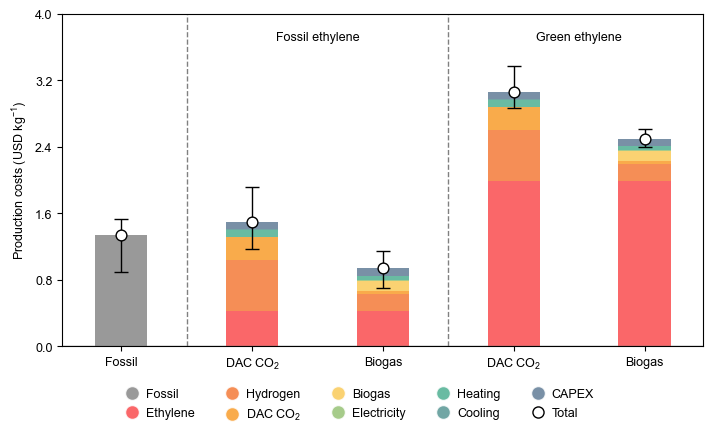

In [18]:
fig, ax1 = plt.subplots(1, 1, figsize = (fig_length[2], fig_height*0.4))

economics_df_final.plot(kind = 'bar', stacked = True, ax = ax1, color = colors_steps, alpha=0.8, width=0.4)
ax1.legend([], frameon = False)
ax1.set_ylabel('Production costs (USD kg$^\mathdefault{-1}$)')
ax1.scatter(x_pts_steps, economics_df['Total'], s = 60, facecolor = 'white', edgecolors = '#000000', linewidths=1, zorder=2)
# ax1.scatter(x_pts_steps, economics_df['Impact 2050'], s = 20, facecolor = '#6e00a3', edgecolors = '#ffffff', marker = 'D', zorder=2)
ax1.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 1)
ax1.axvline(x = 0.5, color = '#808080', linestyle = '--', linewidth = 1)
ax1.axvline(x = 2.5, color = '#808080', linestyle = '--', linewidth = 1)
ax1.errorbar(
    x_pts_steps,
    economics_df['Total'],
    yerr = (economics_df['Total'] - economics_df['Low'], economics_df['High'] - economics_df['Total']),
    fmt = 'none',
    ecolor = '#000000',
    elinewidth = 1,
    capsize = 5,
    capthick = 1,
    zorder = 1,
)
ax1.set_ylim([0.0, 4.0])
# ax1.text(0.5, 1.85, 'Fossil', ha = 'center', color = '#808080', fontsize = fontsize_title)
# ax1.text(2.5, 1.85, 'Green', ha = 'center', color = '#808080', fontsize = fontsize_title)
ax1.yaxis.set_major_locator(MaxNLocator(5))
ax1.set_xticks(x_pts_steps)  
ax1.set_xticklabels(x_labels_steps, rotation = 0)  
# ax1.xaxis.set_tick_params(rotation = 45, pad=-2.5)

labels = ['Fossil', 'Ethylene', 'Hydrogen', 'DAC CO$_\mathdefault{2}$', 'Biogas', 'Electricity', 'Heating', 'Cooling', 'CAPEX', 'Total']
handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 10, alpha=0.8, linewidth=0.0) for color in colors_steps]
handles = handles + [plt.Line2D([0], [0], marker = 'o', color = 'k', markerfacecolor = '#ffffff', markersize = 8, linewidth = 0.0)]
handles = handles + [plt.Line2D([0], [0], marker = 'D', color = 'w', markerfacecolor = '#6e00a3', markersize = 8, linewidth = 0.0)]
legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.02), ncol = 5, frameon = False, handletextpad = 0.1)

ymax = ax1.get_ylim()[1]
ax1.text(1.5, ymax*0.92, 'Fossil ethylene', ha='center', color='#000000', fontsize=9)
ax1.text(3.5, ymax*0.92, 'Green ethylene', ha='center', color='#000000', fontsize=9)

filepath = os.path.join('..', 'results', 'plots', 'economics')
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 600)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 600)

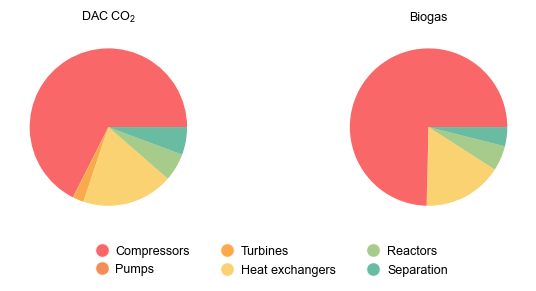

In [19]:
fig, axs = plt.subplots(1, 2, figsize = (fig_length[2], fig_height*0.25))

pie_colors = ['#f94144cc', '#f3722ccc', '#f8961ecc', '#f9c74fcc', '#90be6dcc', '#43aa8bcc']

ax1 = axs[0]
equipment = ['Compressors', 'Pumps', 'Turbines', 'Heat exchangers', 'Reactors', 'Separation']
values = [7.01, 0.01, 0.23, 1.95, 0.59, 0.59]
ax1.pie(values, startangle=0, colors=['#f94144cc', '#f3722ccc', '#f8961ecc', '#f9c74fcc', '#90be6dcc', '#43aa8bcc'])
ax1.set_title('DAC CO$_\mathdefault{2}$', fontsize=9)

ax2 = axs[1]
equipment = ['Compressors', 'Pumps', 'Turbines', 'Heat exchangers', 'Reactors', 'Separation']
values = [8.54, 0.01, 0.00, 1.86, 0.59, 0.45]
ax2.pie(values, startangle=0, colors=['#f94144cc', '#f3722ccc', '#f8961ecc', '#f9c74fcc', '#90be6dcc', '#43aa8bcc'] )
ax2.set_title('Biogas', fontsize=9)

labels = ['Compressors', 'Pumps', 'Turbines', 'Heat exchangers', 'Reactors', 'Separation']
handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 10, alpha=0.8, linewidth=0.0) for color in pie_colors]
legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.02), ncol = 3, frameon = False, handletextpad = 0.1)

fig.tight_layout()

filepath = os.path.join('..', 'results', 'plots', 'CAPEX')
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 600)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 600)

In [20]:
climate_change_df = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'climate_change_impacts', index_col = 0)
climate_change_df_final = climate_change_df.drop(columns = ['Total', 'Low', 'High', 'STDEV', 'Impact 2050'])
climate_change_df_final

,Scenario,Fossil,Ethylene,Hydrogen,Carbon dioxide,Biogas,Electricity,Heating,Cooling,Direct emissions
0,Fossil,4.421392,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,DAC CO2 + wind H2 + fossil C2H4,0.000000,1.158348,0.213258,-0.685001,0.000000,0.071344,0.613976,0.255688,0.022672
2,Biogas + fossil C2H4,0.000000,1.156437,0.072433,-0.077105,-0.472832,0.126728,0.308978,0.034981,0.200579
3,DAC CO2 + wind H2 + green C2H4,0.000000,-0.661734,0.213258,-0.685001,0.000000,0.071344,0.613976,0.255688,0.022672
4,Biogas + green C2H4,0.000000,-0.660641,0.072433,-0.077105,-0.472832,0.126728,0.308978,0.034981,0.200579


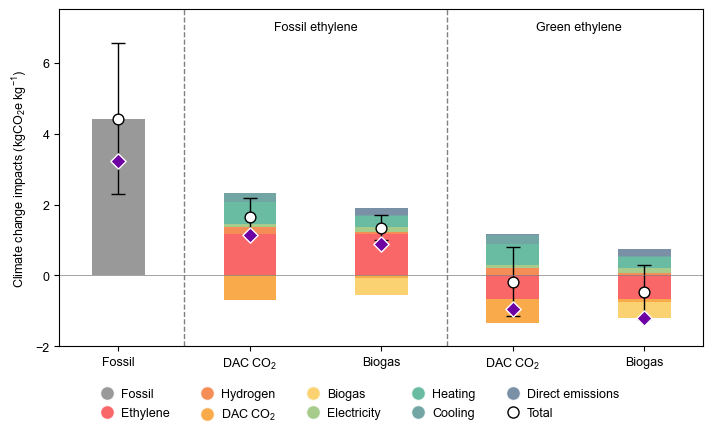

In [21]:
fig, ax1 = plt.subplots(1, 1, figsize = (fig_length[2], fig_height*0.4))

climate_change_df_final.plot(kind = 'bar', stacked = True, ax = ax1, color = colors_steps, alpha=0.8, width=0.4)
ax1.legend([], frameon = False)
ax1.set_ylabel('Climate change impacts (kgCO$_\mathdefault{2}$e kg$^\mathdefault{-1}$)')
ax1.scatter(x_pts_steps, climate_change_df['Total'], s = 60, facecolor = 'white', edgecolors = '#000000', linewidths=1, zorder=2)
ax1.scatter(x_pts_steps, climate_change_df['Impact 2050'], s = 60, facecolor = '#6e00a3', edgecolors = '#ffffff', marker = 'D', zorder=2)
ax1.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
ax1.axvline(x = 0.5, color = '#808080', linestyle = '--', linewidth = 1)
ax1.axvline(x = 2.5, color = '#808080', linestyle = '--', linewidth = 1)
ax1.errorbar(
    x_pts_steps,
    climate_change_df['Total'],
    yerr = (climate_change_df['Total'] - climate_change_df['Low'], climate_change_df['High'] - climate_change_df['Total']),
    fmt = 'none',
    ecolor = '#000000',
    elinewidth = 1,
    capsize = 5,
    capthick = 1,
    zorder = 1,
)
ax1.set_ylim([-2.0, 7.5])
# ax1.text(0.5, 1.85, 'Fossil', ha = 'center', color = '#808080', fontsize = fontsize_title)
# ax1.text(2.5, 1.85, 'Green', ha = 'center', color = '#808080', fontsize = fontsize_title)
ax1.yaxis.set_major_locator(MaxNLocator(5))
ax1.set_xticks(x_pts_steps)  
ax1.set_xticklabels(x_labels_steps, rotation = 0)  
# ax1.xaxis.set_tick_params(rotation = 45, pad=-2.5)

labels = ['Fossil', 'Ethylene', 'Hydrogen', 'DAC CO$_\mathdefault{2}$', 'Biogas', 'Electricity', 'Heating', 'Cooling', 'Direct emissions', 'Total']
handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 10, alpha=0.8, linewidth=0.0) for color in colors_steps]
handles = handles + [plt.Line2D([0], [0], marker = 'o', color = 'k', markerfacecolor = '#ffffff', markersize = 8, linewidth = 0.0)]
handles = handles + [plt.Line2D([0], [0], marker = 'D', color = 'w', markerfacecolor = '#6e00a3', markersize = 8, linewidth = 0.0)]
legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.02), ncol = 5, frameon = False, handletextpad = 0.1)

ymax = ax1.get_ylim()[1]
ax1.text(1.5, ymax*0.92, 'Fossil ethylene', ha='center', color='#000000', fontsize=9)
ax1.text(3.5, ymax*0.92, 'Green ethylene', ha='center', color='#000000', fontsize=9)

filepath = os.path.join('..', 'results', 'plots', 'climate_change_impacts')
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 600)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 600)

In [22]:
cliamte_change_2050_df = pd.read_excel(os.path.join('..', 'results', results_file), sheet_name = 'climate_change_impacts_2050', index_col = 0)
cliamte_change_2050_df_final = cliamte_change_2050_df.drop(columns = ['Total'])
cliamte_change_2050_df_final

,Scenario,Fossil,Ethylene,Hydrogen,Carbon dioxide,Biogas,Electricity,Heating,Cooling,Direct emissions
0,Fossil,3.233107,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,DAC CO2 + wind H2 + fossil C2H4,0.000000,0.911403,0.129723,-0.703993,0.000000,0.000634,0.597291,0.174429,0.022672
2,Biogas + fossil C2H4,0.000000,0.909898,0.044060,-0.079243,-0.512149,0.001127,0.300581,0.023193,0.200579
3,DAC CO2 + wind H2 + green C2H4,0.000000,-1.174882,0.129723,-0.703993,0.000000,0.000634,0.597291,0.174429,0.022672
4,Biogas + green C2H4,0.000000,-1.172942,0.044060,-0.079243,-0.512149,0.001127,0.300581,0.023193,0.200579


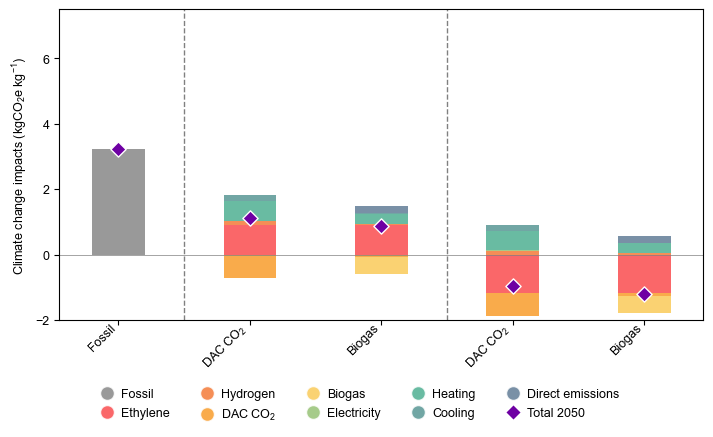

In [23]:
fig, ax1 = plt.subplots(1, 1, figsize = (fig_length[2], fig_height*0.4))

cliamte_change_2050_df_final.plot(kind = 'bar', stacked = True, ax = ax1, color = colors_steps, alpha=0.8, width=0.4)
ax1.legend([], frameon = False)
ax1.set_ylabel('Climate change impacts (kgCO$_\mathdefault{2}$e kg$^\mathdefault{-1}$)')
ax1.scatter(x_pts_steps, cliamte_change_2050_df['Total'], s = 60, facecolor = '#6e00a3', edgecolors = '#ffffff', marker = 'D', zorder=2)
ax1.axhline(y = 0.0, color = '#808080', linestyle = '-', linewidth = 0.5)
ax1.axvline(x = 0.5, color = '#808080', linestyle = '--', linewidth = 1)
ax1.axvline(x = 2.5, color = '#808080', linestyle = '--', linewidth = 1)
ax1.set_ylim([-2.0, 7.5])
# ax1.text(0.5, 1.85, 'Fossil', ha = 'center', color = '#808080', fontsize = fontsize_title)
# ax1.text(2.5, 1.85, 'Green', ha = 'center', color = '#808080', fontsize = fontsize_title)
ax1.yaxis.set_major_locator(MaxNLocator(5))
ax1.set_xticks(x_pts_steps)  
ax1.set_xticklabels(x_labels_steps, rotation = 45, ha = 'right')  
ax1.xaxis.set_tick_params(rotation = 45, pad=-2.5)

labels = ['Fossil', 'Ethylene', 'Hydrogen', 'DAC CO$_\mathdefault{2}$', 'Biogas', 'Electricity', 'Heating', 'Cooling', 'Direct emissions', 'Total 2050']
handles = [plt.Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = color, markersize = 10, alpha=0.8, linewidth=0.0) for color in colors_steps]
handles = handles + [plt.Line2D([0], [0], marker = 'D', color = 'w', markerfacecolor = '#6e00a3', markersize = 8, linewidth = 0.0)]
handles = handles + [plt.Line2D([0], [0], marker = 'D', color = 'w', markerfacecolor = '#6e00a3', markersize = 8, linewidth = 0.0)]
legend = fig.legend(handles = handles, labels = labels, loc = 'upper center', bbox_to_anchor = (0.5, 0.02), ncol = 5, frameon = False, handletextpad = 0.1)

filepath = os.path.join('..', 'results', 'plots', 'climate_change_impacts_2050')
plt.savefig(filepath + '.png', format = 'png', bbox_inches = 'tight', dpi = 600)
plt.savefig(filepath + '.svg', format = 'svg', bbox_inches = 'tight', dpi = 600)

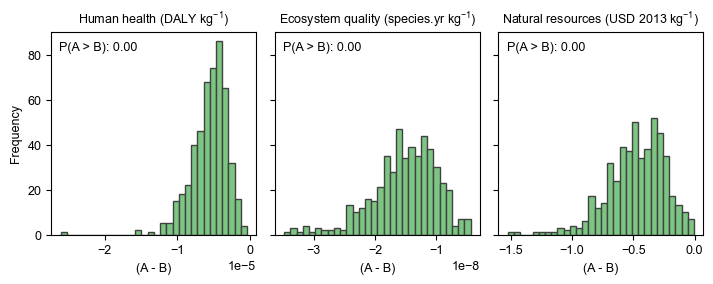

In [24]:
human_health_df = pd.read_excel(os.path.join('..', 'results', 'human_health_monte_carlo.xlsx'), sheet_name = 'Sheet1', index_col = 0)
ecosystem_quality_df = pd.read_excel(os.path.join('..', 'results', 'ecosystem_quality_monte_carlo.xlsx'), sheet_name = 'Sheet1', index_col = 0)
natural_resources_df = pd.read_excel(os.path.join('..', 'results', 'natural_resources_monte_carlo.xlsx'), sheet_name = 'Sheet1', index_col = 0)

fig, axs = plt.subplots(1, 3, figsize=(fig_length[2], fig_height*0.3), sharey=True)

ax = axs[0]
data = human_health_df['propanol production, biogas, fossil ethylene'].values - human_health_df['propanol production, fossil'].values
bins = 30
n, bins, patches = ax.hist(data, bins=bins, alpha=1, edgecolor='#414141')

for i in range(len(patches)):
    if bins[i] > 0:
        patches[i].set_facecolor('#ff8383')
    else:
        patches[i].set_facecolor('#7cc582')

# ['#f94144cc', '#f3722ccc', '#f8961ecc', '#f9c74fcc', '#90be6dcc', '#43aa8bcc']
mean_value = data.mean()
positive_prob = (data > 0).sum() / len(data)  # Calculate the probability of x > 0
ax.text(0.04, 0.95, f'P(A > B): {positive_prob:.2f}', transform=ax.transAxes,
        verticalalignment='top')  # Display probability
ax.set_title('Human health (DALY kg$^\mathdefault{-1}$)', fontsize=9)
ax.set_xlabel('(A - B)')
ax.set_ylabel('Frequency')

ax = axs[1]
data = ecosystem_quality_df['propanol production, biogas, fossil ethylene'].values - ecosystem_quality_df['propanol production, fossil'].values
bins = 30
n, bins, patches = ax.hist(data, bins=bins, alpha=1, edgecolor='#414141')

for i in range(len(patches)):
    if bins[i] > 0:
        patches[i].set_facecolor('#ff8383')
    else:
        patches[i].set_facecolor('#7cc582')
mean_value = data.mean()
positive_prob = (data > 0).sum() / len(data)  # Calculate the probability of x > 0
ax.text(0.04, 0.95, f'P(A > B): {positive_prob:.2f}', transform=ax.transAxes,
        verticalalignment='top')  # Display probability
ax.set_title('Ecosystem quality (species.yr kg$^\mathdefault{-1}$)', fontsize=9)
ax.set_xlabel('(A - B)')

ax = axs[2]
data = natural_resources_df['propanol production, biogas, fossil ethylene'].values - natural_resources_df['propanol production, fossil'].values
bins = 30
n, bins, patches = ax.hist(data, bins=bins, alpha=1, edgecolor='#414141')

for i in range(len(patches)):
    if bins[i] > 0:
        patches[i].set_facecolor('#ff8383')
    else:
        patches[i].set_facecolor('#7cc582')
mean_value = data.mean()
positive_prob = (data > 0).sum() / len(data)  # Calculate the probability of x > 0
ax.text(0.04, 0.95, f'P(A > B): {positive_prob:.2f}', transform=ax.transAxes,
        verticalalignment='top')  # Display probability
ax.set_title('Natural resources (USD 2013 kg$^\mathdefault{-1}$)', fontsize=9)
ax.set_xlabel('(A - B)')

filepath = os.path.join('..', 'results', 'plots', 'burden_shifting')
plt.savefig(filepath + '.png', format='png', bbox_inches='tight', dpi=600)
plt.savefig(filepath + '.svg', format='svg', bbox_inches='tight', dpi=600)